# Exploratory Data Analysis (EDA): Heart Disease Dataset
This section explores the UCI/Kaggle Heart Disease dataset prior to the data degradation experiments. We will visualize data distributions, feature relationships, and correlations to establish a baseline understanding of the clean dataset.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: Data Loading & Basic Overview
First, we load the dataset and look at the raw tabular data, its structure, and standard statistical summaries to check for missing values or obvious anomalies.

In [10]:
df = pd.read_csv('heart_disease.csv')

# 1. Display the first 5 rows (Tabular View)
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# 2. Dataset Info (Datatypes and Non-Null Counts)
print("\n--- Dataset Information ---")
df.info()

# 3. Summary Statistics for Numerical Features (Tabular View)
print("\n--- Summary Statistics ---")
display(df.describe().T)

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- First 5 Rows of the Dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2



--- Missing Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Part 2: Target Variable Distribution
Understanding our target variable (`target`): 1 = Presence of heart disease, 0 = Absence.

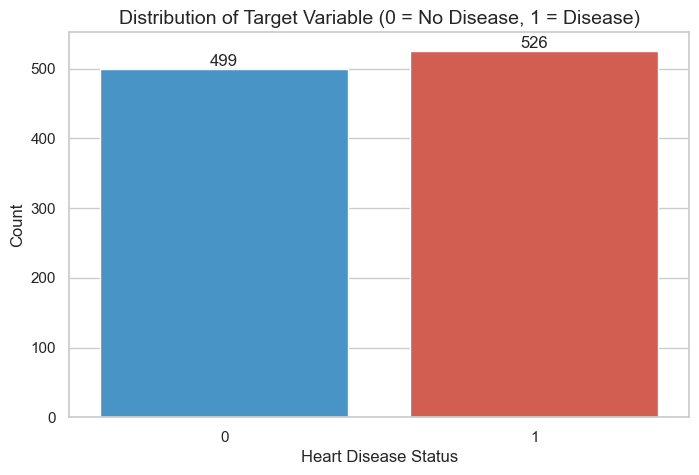

In [11]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='target', palette=['#3498db', '#e74c3c'])

plt.title('Distribution of Target Variable (0 = No Disease, 1 = Disease)', fontsize=14)
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

## Part 3: Univariate & Bivariate Analysis
Visualizing continuous and categorical features, and how they relate to the target variable.

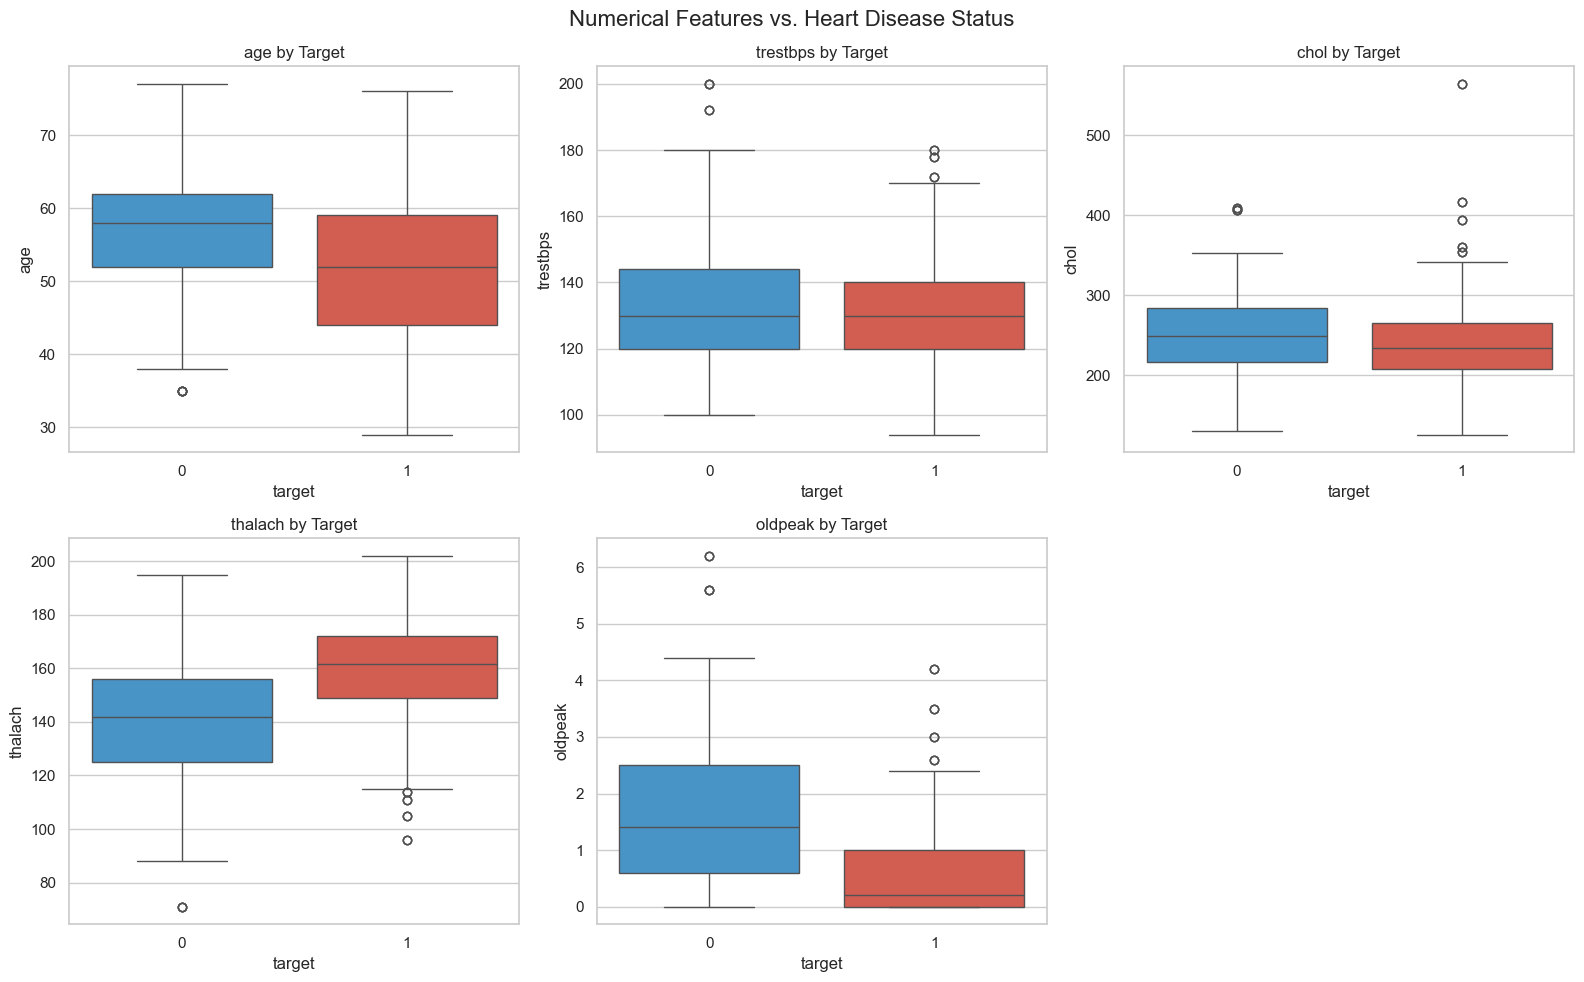

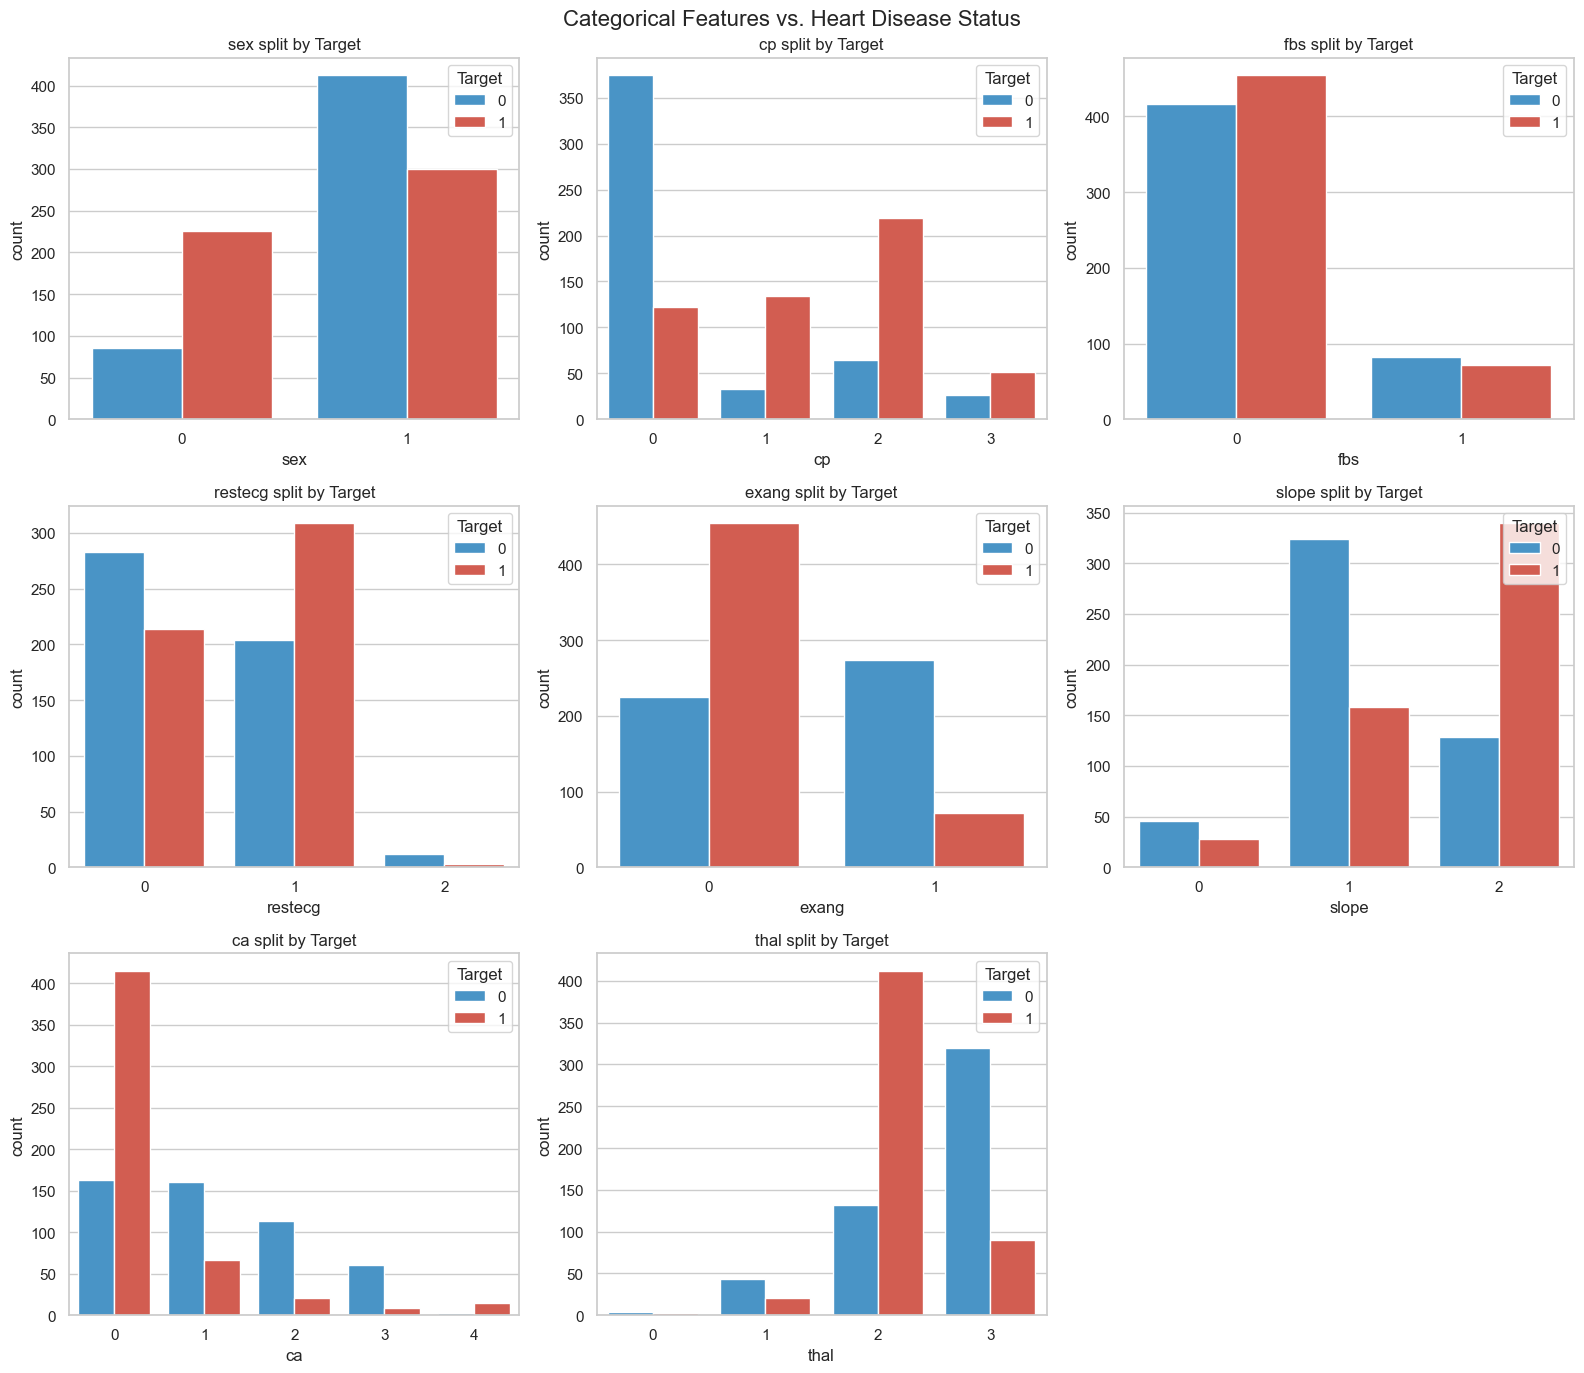

In [12]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 1. Numerical Features vs Target
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
fig.suptitle('Numerical Features vs. Heart Disease Status', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} by Target', fontsize=12)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 2. Categorical Features vs Target
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
fig.suptitle('Categorical Features vs. Heart Disease Status', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} split by Target', fontsize=12)
    axes[i].legend(title='Target', loc='upper right')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Part 4: Correlation Matrix
Identifying linear relationships between features.

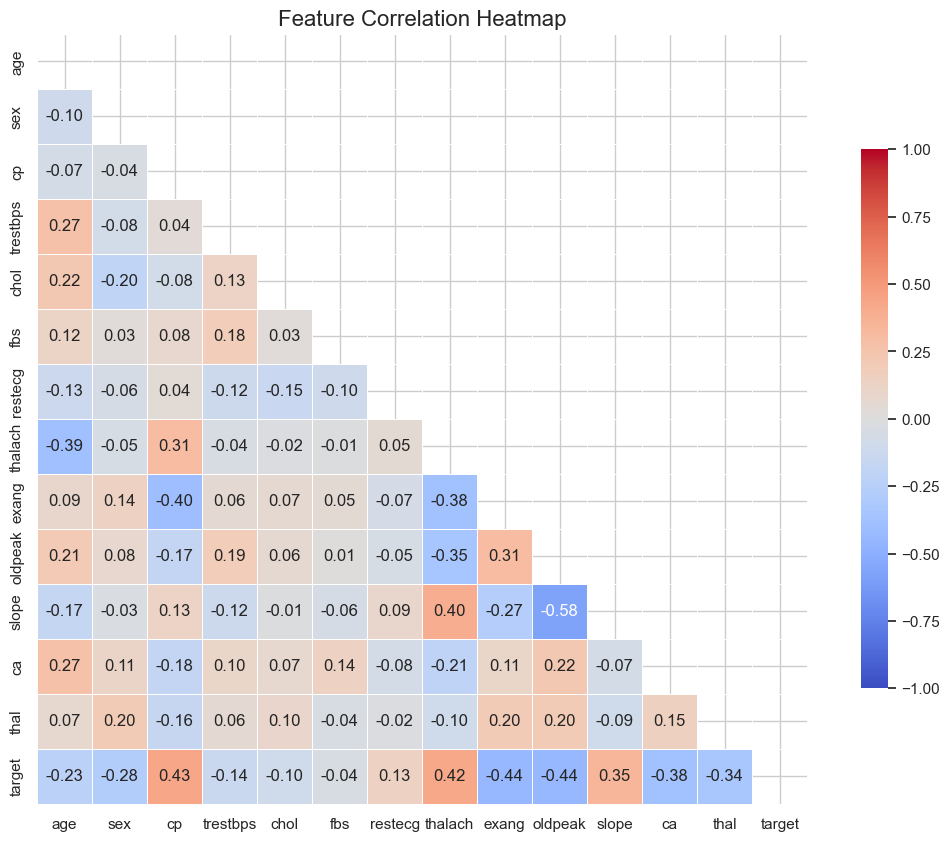

In [13]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

# Experiment: Model Degradation against Noisy Datasets
This section executes the methodology defined in the paper. We inject Additive White Gaussian Noise (AWGN) incrementally into the test set's numerical features to observe how different machine learning architectures degrade.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score)

def load_data(filepath="heart_disease.csv"):
    df = pd.read_csv(filepath)
    num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
    target = 'target'
    return df.drop(columns=[target]), df[target], num_cols, cat_cols

def inject_gaussian_noise(X_numerical, noise_percentage):
    if noise_percentage == 0:
        return X_numerical.copy()
    X_noisy = X_numerical.copy()
    for col in X_noisy.columns:
        noise_std = X_noisy[col].std() * noise_percentage
        noise = np.random.normal(0, noise_std, size=len(X_noisy[col]))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }

def calculate_performance_decay(baseline_metrics, noisy_metrics):
    decay_rates = {}
    for metric, m_base in baseline_metrics.items():
        m_noise = noisy_metrics[metric]
        decay_rates[metric] = 0.0 if m_base == 0 else ((m_base - m_noise) / m_base) * 100
    return decay_rates

## Part 5: Run the Experiment Pipeline
Train models on clean data and evaluate them across varying levels of noise (0% to 50%).

In [15]:
# 1. Setup Data & Models
X, y, num_cols, cat_cols = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ])

models = {
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

noise_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
results = {model_name: {} for model_name in models.keys()}

print("Running degradations... this may take a moment.")

# 2. Main Experiment Loop
for model_name, model in models.items():
    X_train_processed = preprocessor.fit_transform(X_train)
    model.fit(X_train_processed, y_train)
    
    baseline_metrics = None
    
    for noise in noise_levels:
        X_test_noisy = X_test.copy()
        X_test_noisy[num_cols] = inject_gaussian_noise(X_test[num_cols], noise)
        X_test_processed = preprocessor.transform(X_test_noisy)
        
        y_pred = model.predict(X_test_processed)
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        
        metrics = calculate_metrics(y_test, y_pred, y_prob)
        
        if noise == 0.0:
            baseline_metrics = metrics
            decay = {m: 0.0 for m in metrics}
        else:
            decay = calculate_performance_decay(baseline_metrics, metrics)
        
        results[model_name][noise] = {"metrics": metrics, "decay": decay}

print("Experiment Complete! Results stored in memory.")

Running degradations... this may take a moment.
Experiment Complete! Results stored in memory.


## Part 6: Tabular Results & Degradation Curves
Visualizing the exact breakdown points and model stability.

--- Matthews Correlation Coefficient (MCC) by Noise Level ---


,Model,MCC (0%),MCC (10%),MCC (20%),MCC (30%),MCC (40%),MCC (50%)
0,SVM,0.7532,0.7621,0.7604,0.7317,0.7444,0.6941
1,Random Forest,1.0000,0.9903,0.9523,0.8947,0.9040,0.7996
2,XGBoost,0.9712,0.9219,0.8540,0.7589,0.6991,0.7694
3,MLP,0.9712,0.9712,0.9712,0.9221,0.9024,0.8156


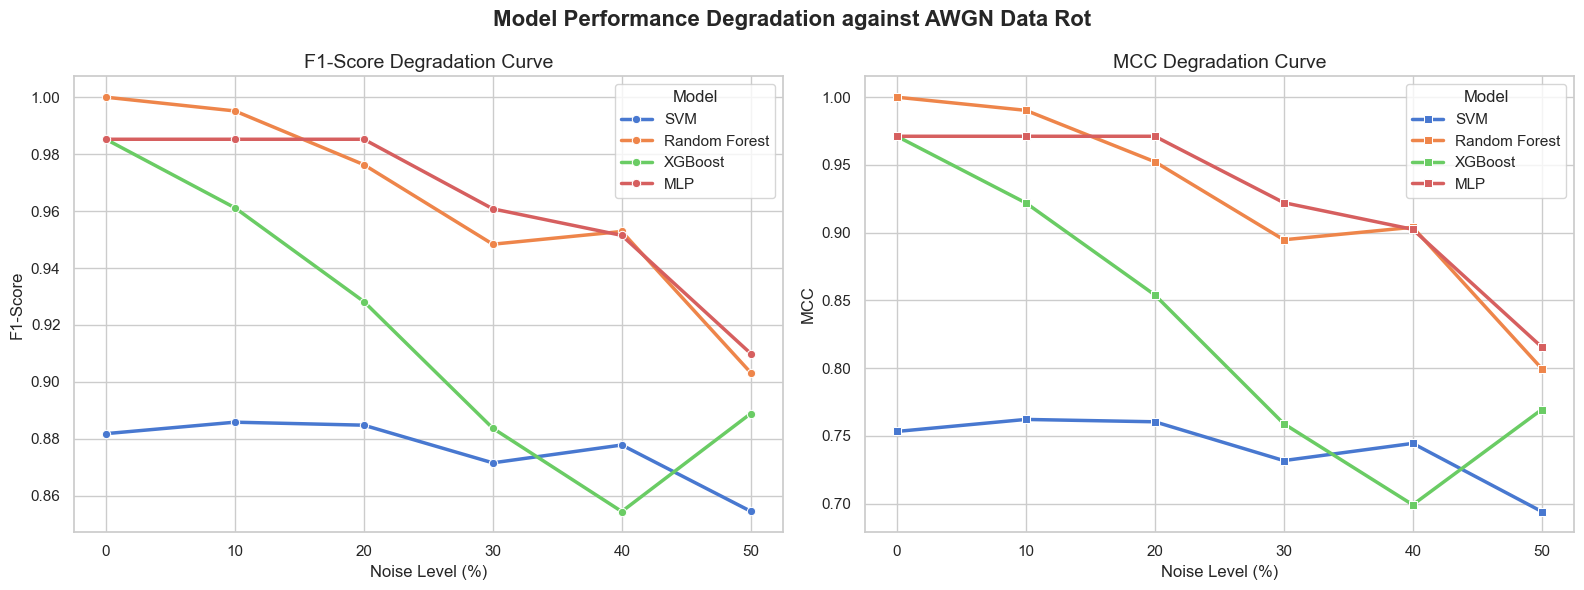


--- Critical Breakdown Point (BP_crit) Analysis ---
❌ SVM: Catastrophic collapse reached at 50% noise.
❌ Random Forest: Catastrophic collapse reached at 50% noise.
❌ XGBoost: Catastrophic collapse reached at 30% noise.
❌ MLP: Catastrophic collapse reached at 50% noise.


In [16]:
# --- Table Generation ---
table_data = []
for model_name in models.keys():
    row = {"Model": model_name}
    for noise in noise_levels:
        row[f"MCC ({int(noise*100)}%)"] = round(results[model_name][noise]["metrics"]["MCC"], 4)
    table_data.append(row)

print("--- Matthews Correlation Coefficient (MCC) by Noise Level ---")
display(pd.DataFrame(table_data))

# --- Graph Generation ---
plot_data = []
for model_name in models.keys():
    for noise in noise_levels:
        plot_data.append({
            "Model": model_name,
            "Noise Level": noise * 100,
            "F1-Score": results[model_name][noise]["metrics"]["F1-Score"],
            "MCC": results[model_name][noise]["metrics"]["MCC"]
        })

df_plot = pd.DataFrame(plot_data)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Degradation against AWGN Data Rot', fontsize=16, fontweight='bold')

sns.lineplot(data=df_plot, x="Noise Level", y="F1-Score", hue="Model", marker="o", ax=axes[0], linewidth=2.5)
axes[0].set_title('F1-Score Degradation Curve', fontsize=14)
axes[0].set_xlabel('Noise Level (%)', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)

sns.lineplot(data=df_plot, x="Noise Level", y="MCC", hue="Model", marker="s", ax=axes[1], linewidth=2.5)
axes[1].set_title('MCC Degradation Curve', fontsize=14)
axes[1].set_xlabel('Noise Level (%)', fontsize=12)
axes[1].set_ylabel('MCC', fontsize=12)

plt.tight_layout()
plt.show()

# --- BP_crit Analysis ---
print("\n--- Critical Breakdown Point (BP_crit) Analysis ---")
for model_name in models.keys():
    mcc_baseline = results[model_name][0.0]["metrics"]["MCC"]
    mcc_all_levels = [results[model_name][n]["metrics"]["MCC"] for n in noise_levels]
    mcc_std = np.std(mcc_all_levels)
    
    bp_crit = next((n for n in noise_levels if (mcc_baseline - results[model_name][n]["metrics"]["MCC"]) > (2 * mcc_std)), None)
            
    if bp_crit is not None:
        print(f"\u274C {model_name}: Catastrophic collapse reached at {int(bp_crit*100)}% noise.")
    else:
        print(f"\u2705 {model_name}: Maintained stability (within 2 std devs) up to 50% noise.")